In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score, precision_score,recall_score,classification_report,confusion_matrix)

In [23]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [24]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
data.shape

(7043, 21)

In [26]:
# Convert TotalCharges to numeric
data['TotalCharges'] = pd.to_numeric(
    data['TotalCharges'],
    errors='coerce'
)

# Remove missing values
data = data.dropna()

# Remove customerID column
data = data.drop('customerID', axis=1)

data.shape

(7032, 20)

In [27]:
encoder = LabelEncoder()

categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [28]:
X = data.drop('Churn', axis=1)

y = data['Churn']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Size:", len(X_train))

print("Testing Data Size:", len(X_test))


Training Data Size: 5625
Testing Data Size: 1407


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)



Logistic Regression Model Trained Successfully!


c:\Users\nikhi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
print("\nFirst 5 Coefficients:")
print(model.coef_[0][:5])

print("\nIntercept:")
print(model.intercept_[0])


First 5 Coefficients:
[-0.03369991  0.27452712  0.0744908  -0.24058733 -0.0601069 ]

Intercept:
-0.504912252739861


In [32]:
y_pred = model.predict(X_test)

In [33]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

print("\nAccuracy Score:", accuracy)

print("Precision Score:", precision)

print("Recall Score:", recall)


Accuracy Score: 0.7867803837953091
Precision Score: 0.625
Recall Score: 0.4946524064171123


In [34]:
print("\nClassification Report:")

report = classification_report(y_test, y_pred)

print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



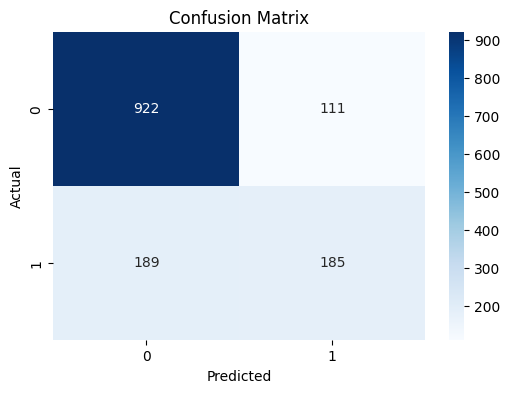

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [36]:
sample_data = X.iloc[[0]]

prediction = model.predict(sample_data)

probability = model.predict_proba(sample_data)

print("\nPrediction:", prediction[0])

print("Churn Probability:", probability[0][1])


Prediction: 1
Churn Probability: 0.601019885303243
